In [3]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Cargar el dataset
df = pd.read_csv('E:/Bootcamp/credit card/CC GENERAL.csv')

# Eliminar la columna de identificación de cliente (CUST_ID)
df = df.drop(columns=['CUST_ID'])

# Limpieza de datos: manejar valores faltantes
df.fillna(df.mean(), inplace=True)

# Seleccionar características relevantes para el clustering
features = df[['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 
               'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PAYMENTS']]

# Estandarización de las características
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Verificar los datos estandarizados
print(scaled_features[:5])


[[-0.73198937 -0.42489974 -0.35693402 -0.34907882 -0.46678555 -0.52897879]
 [ 0.78696085 -0.46955188 -0.35693402 -0.45457623  2.60560451  0.81864213]
 [ 0.44713513 -0.10766823  0.10888851 -0.45457623 -0.46678555 -0.38380474]
 [ 0.04909914  0.23205785  0.54618946 -0.45457623 -0.36865325 -0.59868826]
 [-0.3587753  -0.46206305 -0.34729428 -0.45457623 -0.46678555 -0.3643678 ]]


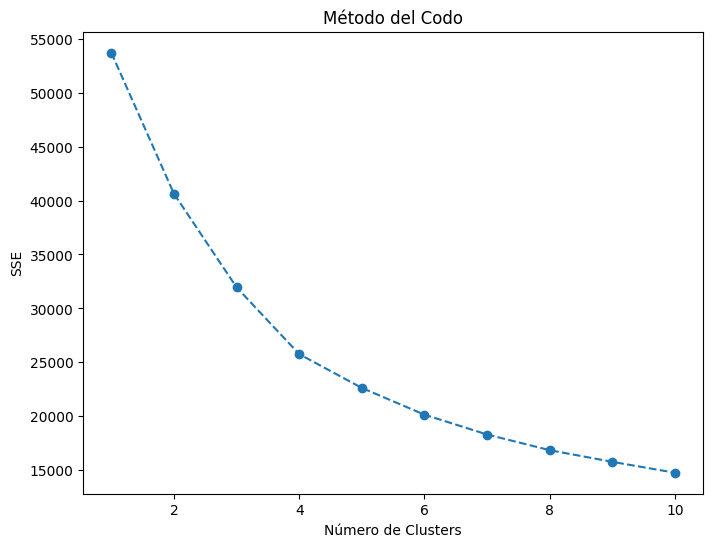

Silhouette Score (K-means): 0.5522118189107313
Calinski-Harabasz Index (K-means): 3233.984652181183


In [4]:
# Método del codo para determinar el número óptimo de clusters
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), sse, marker='o', linestyle='--')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters')
plt.ylabel('SSE')
plt.show()

# Aplicar K-means con el número óptimo de clusters (supongamos K=4)
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(scaled_features)

# Evaluación del Silhouette Score y Calinski-Harabasz Index
silhouette_kmeans = silhouette_score(scaled_features, y_kmeans)
calinski_kmeans = calinski_harabasz_score(scaled_features, y_kmeans)

print(f'Silhouette Score (K-means): {silhouette_kmeans}')
print(f'Calinski-Harabasz Index (K-means): {calinski_kmeans}')


In [5]:
# Aplicar DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(scaled_features)

# Evaluar el Silhouette Score y Calinski-Harabasz Index (si no hay un solo cluster)
if len(set(y_dbscan)) > 1:
    silhouette_dbscan = silhouette_score(scaled_features, y_dbscan)
    calinski_dbscan = calinski_harabasz_score(scaled_features, y_dbscan)
else:
    silhouette_dbscan = -1  # Si DBSCAN no encuentra clusters significativos
    calinski_dbscan = -1

print(f'Silhouette Score (DBSCAN): {silhouette_dbscan}')
print(f'Calinski-Harabasz Index (DBSCAN): {calinski_dbscan}')


Silhouette Score (DBSCAN): 0.13564312820627483
Calinski-Harabasz Index (DBSCAN): 261.00288743022236


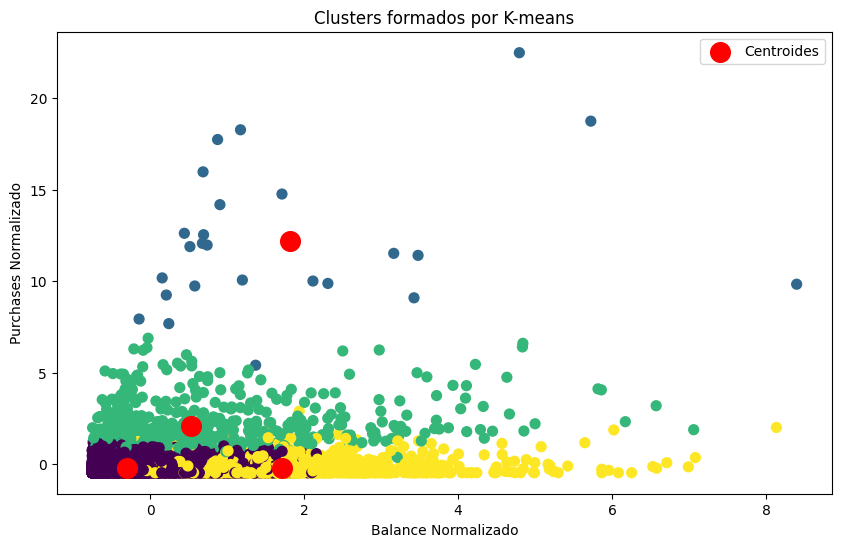

In [6]:
# Gráfico de los clusters formados por K-means
plt.figure(figsize=(10, 6))
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', label='Centroides')
plt.title('Clusters formados por K-means')
plt.xlabel('Balance Normalizado')
plt.ylabel('Purchases Normalizado')
plt.legend()
plt.show()


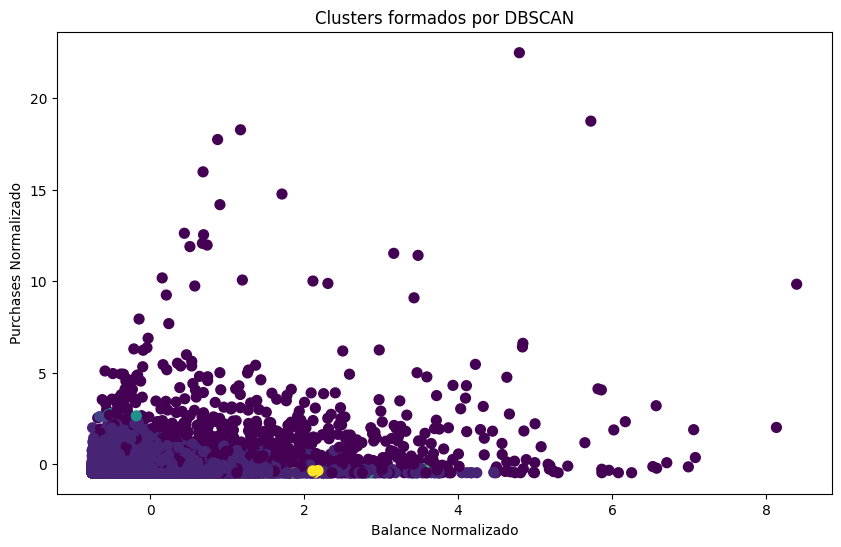

In [7]:
# Gráfico de los clusters formados por DBSCAN
plt.figure(figsize=(10, 6))
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=y_dbscan, s=50, cmap='viridis')
plt.title('Clusters formados por DBSCAN')
plt.xlabel('Balance Normalizado')
plt.ylabel('Purchases Normalizado')
plt.show()
